<div style="background:linear-gradient(120deg,#01172F 0%,#082744 55%,#14476B 100%);
            border-radius:14px;padding:34px 38px;color:#EAEFF5;
            font-family:system-ui,-apple-system,'Segoe UI',sans-serif;">
  <div style="display:inline-block;border:1px solid #D9A441;color:#D9A441;
              border-radius:999px;padding:3px 13px;font-size:12px;
              letter-spacing:1.6px;font-weight:700;">ENTREGA 3 &nbsp;·&nbsp; PCB DEFECTS / KERAS</div>
  <h1 style="margin:16px 0 6px 0;font-size:34px;line-height:1.15;color:#FFFFFF;">
     Classificação e <span style="color:#D9A441;">análise de defeitos</span> em PCBs
  </h1>
  <p style="margin:0;font-size:16px;color:#A9BCD0;max-width:820px;">
     Um pipeline de classificação de imagens com <b style="color:#EAEFF5;">TensorFlow + Keras</b>:
     baseline, regiões de interesse, treinamento regularizado, Transfer Learning,
     calibração probabilística e análise das representações aprendidas.
  </p>
  <div style="margin-top:22px;display:flex;gap:26px;flex-wrap:wrap;font-size:13px;color:#A9BCD0;">
    <div><span style="color:#D9A441;font-weight:700;">Dataset</span><br>PCB Defects · 6 classes</div>
    <div><span style="color:#D9A441;font-weight:700;">Modelos</span><br>baseline + CNN principal</div>
    <div><span style="color:#D9A441;font-weight:700;">Treinamento</span><br>augmentation · checkpoints · early stopping</div>
    <div><span style="color:#D9A441;font-weight:700;">Análise</span><br>calibração · confusão · FFT · PCA · K-Means</div>
  </div>
</div>

---

### O que este notebook faz

O objetivo é classificar seis tipos de defeitos em placas de circuito impresso e, ao mesmo tempo, verificar **onde o modelo aprende, onde falha e quão confiáveis são suas predições**.

| # | Movimento | Pergunta |
|---|---|---|
| 1 | Conhecer o dado | O que existe no dataset e como os defeitos estão anotados? |
| 2 | Particionar com cuidado | Como impedir que o mesmo layout-base de PCB vaze entre treino e teste? |
| 3 | Criar uma baseline | A imagem completa contém sinal suficiente para classificar o defeito? |
| 4 | Extrair ROIs | O desempenho melhora quando a CNN recebe diretamente a região anotada? |
| 5 | Melhorar o treinamento | Augmentation, regularização e controle da taxa de aprendizado ajudam? |
| 6 | Comparar modelos | Uma CNN pré-treinada oferece um benchmark competitivo? |
| 7 | Calibrar | As probabilidades previstas refletem a frequência real de acertos? |
| 8 | Interpretar | FFT, embeddings, PCA e K-Means revelam estrutura adicional? |

> **Não há mágica. Há matemática!** 🧙 — e uma boa acurácia é apenas o começo.

---

> ### ⚠️ Aviso
> Este é um **exercício acadêmico de visão computacional**. O modelo é avaliado em um
> dataset público e **não constitui um sistema industrial validado de inspeção de PCBs**.


## 0. Configuração do ambiente

Primeiro definimos bibliotecas, sementes, hiperparâmetros e diretórios. O notebook cria todos os artefatos dentro de `src/`, mantendo a raiz do projeto limpa.

Os valores de épocas abaixo são **limites máximos**: o `EarlyStopping` pode encerrar o treinamento antes.


In [1]:
# ============================================================
# 0.1 IMPORTS
# ============================================================

from pathlib import Path
import json
import platform
import random
import shutil
import sys
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

import sklearn
import scipy

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    silhouette_score,
    adjusted_rand_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from scipy.stats import gaussian_kde
from scipy.optimize import minimize_scalar


In [2]:
# ============================================================
# 0.2 REPRODUTIBILIDADE E PARÂMETROS
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32
NUM_CLASSES = 6

GLOBAL_BASELINE_EPOCHS = 12
ROI_BASELINE_EPOCHS = 20
MAIN_EPOCHS = 35
TRANSFER_EPOCHS = 15

# ROI
ROI_CONTEXT_SCALE = 2.0
ROI_MIN_SIDE = 128

# CNN principal
L2_FACTOR = 1e-4
MAIN_LEARNING_RATE = 3e-4
MAIN_DROPOUT = 0.35

# Transfer Learning
TRANSFER_BACKBONE = "MobileNetV2"
TRANSFER_LEARNING_RATE = 3e-4
TRANSFER_DROPOUT = 0.30

# Calibração
CALIBRATION_BINS = 10
TEMPERATURE_MIN = 0.05
TEMPERATURE_MAX = 10.0

EXPECTED_CLASS_NAMES = [
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper",
]


In [3]:
# ============================================================
# 0.3 ESTRUTURA DE DIRETÓRIOS
# ============================================================

ROOT_DIR = Path.cwd()
SRC_DIR = ROOT_DIR / "src"

DATA_DIR = SRC_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
METADATA_DIR = DATA_DIR / "metadata"

MODELS_DIR = SRC_DIR / "models"

OUTPUTS_DIR = SRC_DIR / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
METRICS_DIR = OUTPUTS_DIR / "metrics"
EXAMPLES_DIR = OUTPUTS_DIR / "examples"

DIRECTORIES = [
    SRC_DIR,
    DATA_DIR,
    RAW_DIR,
    PROCESSED_DIR,
    METADATA_DIR,
    MODELS_DIR,
    OUTPUTS_DIR,
    FIGURES_DIR,
    METRICS_DIR,
    EXAMPLES_DIR,
]

for directory in DIRECTORIES:
    directory.mkdir(parents=True, exist_ok=True)

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("GPU disponível:", bool(tf.config.list_physical_devices("GPU")))
print("Diretório raiz:", ROOT_DIR)


TensorFlow: 2.20.0
Keras: 3.13.2
GPU disponível: True
Diretório raiz: /content


### 0.4 Registro do experimento

Para tornar a execução reprodutível, salvamos as principais versões de bibliotecas e os hiperparâmetros em `src/outputs/metrics/run_config.json`.

Esse arquivo é criado antes do treinamento e complementado por `resultados.json` ao final do notebook.


In [4]:
# ============================================================
# 0.4 REGISTRO PERSISTENTE DO EXPERIMENTO
# ============================================================

RUN_CONFIG = {
    "versions": {
        "python": sys.version.split()[0],
        "platform": platform.platform(),
        "tensorflow": tf.__version__,
        "keras": getattr(keras, "__version__", "unknown"),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "scipy": scipy.__version__,
    },
    "hardware": {
        "gpu_devices": [
            device.name
            for device in tf.config.list_physical_devices("GPU")
        ]
    },
    "reproducibility": {
        "seed": SEED,
    },
    "data": {
        "image_size": list(IMAGE_SIZE),
        "batch_size": BATCH_SIZE,
        "num_classes": NUM_CLASSES,
        "roi_context_scale": ROI_CONTEXT_SCALE,
        "roi_min_side": ROI_MIN_SIDE,
        "split_strategy": "StratifiedGroupKFold por board_id",
    },
    "training": {
        "global_baseline_epochs_max": GLOBAL_BASELINE_EPOCHS,
        "roi_baseline_epochs_max": ROI_BASELINE_EPOCHS,
        "main_epochs_max": MAIN_EPOCHS,
        "transfer_epochs_max": TRANSFER_EPOCHS,
        "main_learning_rate": MAIN_LEARNING_RATE,
        "main_l2": L2_FACTOR,
        "main_dropout": MAIN_DROPOUT,
        "transfer_backbone": TRANSFER_BACKBONE,
        "transfer_learning_rate": TRANSFER_LEARNING_RATE,
        "transfer_dropout": TRANSFER_DROPOUT,
        "early_stopping": True,
        "model_checkpoint": True,
        "reduce_lr_on_plateau": True,
    },
    "calibration": {
        "method": "temperature_scaling",
        "fit_split": "validation",
        "ece_bins": CALIBRATION_BINS,
        "temperature_bounds": [
            TEMPERATURE_MIN,
            TEMPERATURE_MAX,
        ],
    },
}

RUN_CONFIG_PATH = METRICS_DIR / "run_config.json"

with RUN_CONFIG_PATH.open(
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        RUN_CONFIG,
        file,
        indent=2,
        ensure_ascii=False
    )

print(f"Configuração salva em: {RUN_CONFIG_PATH}")


Configuração salva em: /content/src/outputs/metrics/run_config.json


## 1. Conhecendo o dataset

O **PCB Defects** é baixado diretamente do Kaggle. Primeiro conferimos as seis classes e, em seguida, inspecionamos as anotações XML.

As anotações são essenciais: uma PCB pode conter **vários defeitos pequenos**, cada um delimitado por uma *bounding box*. Essa característica será importante para explicar por que a classificação da placa inteira pode apresentar desempenho baixo.


In [5]:
%%bash
# ============================================================
# 1.1 DOWNLOAD DO DATASET — KAGGLE
# ============================================================

set -e

RAW_DIR="src/data/raw"
ZIP_PATH="$RAW_DIR/pcb-defects.zip"
DATASET_DIR="$RAW_DIR/PCB_DATASET"

mkdir -p "$RAW_DIR"

if [ -d "$DATASET_DIR" ]; then
    echo "Dataset já encontrado em: $DATASET_DIR"
else
    echo "Baixando PCB Defects..."

    curl -L \
      -o "$ZIP_PATH" \
      https://www.kaggle.com/api/v1/datasets/download/akhatova/pcb-defects

    echo "Extraindo arquivos..."
    unzip -q -o "$ZIP_PATH" -d "$RAW_DIR"
    rm -f "$ZIP_PATH"

    echo "Dataset baixado e extraído com sucesso."
fi


Baixando PCB Defects...
Extraindo arquivos...
Dataset baixado e extraído com sucesso.


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1920M  100 1920M    0     0   117M      0  0:00:16  0:00:16 --:--:--  151M


In [6]:
# ============================================================
# 1.2 ESTRUTURA E INVENTÁRIO
# ============================================================

DATASET_DIR = RAW_DIR / "PCB_DATASET"
IMAGES_DIR = DATASET_DIR / "images"
ANNOTATIONS_DIR = DATASET_DIR / "Annotations"

if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset não encontrado em {DATASET_DIR}. "
        "Execute primeiro a célula de download."
    )

for path in sorted(DATASET_DIR.iterdir()):
    print(f"[{'DIR ' if path.is_dir() else 'FILE'}] {path.name}")

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

inventory = []

for class_dir in sorted(IMAGES_DIR.iterdir()):
    if not class_dir.is_dir():
        continue

    class_name = class_dir.name.lower()

    images = [
        p for p in class_dir.rglob("*")
        if p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    inventory.append({
        "class_name": class_name,
        "n_images": len(images),
    })

class_distribution = pd.DataFrame(inventory).sort_values("class_name")

actual_classes = sorted(class_distribution["class_name"].tolist())

assert set(actual_classes) == set(EXPECTED_CLASS_NAMES), (
    "As classes encontradas não correspondem às seis classes esperadas.\n"
    f"Encontradas: {actual_classes}"
)

# Mantém uma ordem fixa em todo o notebook.
CLASS_NAMES = EXPECTED_CLASS_NAMES.copy()

display(class_distribution)
print("Total de imagens:", int(class_distribution["n_images"].sum()))


[DIR ] Annotations
[DIR ] PCB_USED
[DIR ] images
[FILE] rotate.py
[DIR ] rotation


,class_name,n_images
0,missing_hole,115
1,mouse_bite,115
2,open_circuit,116
3,short,116
4,spur,115
5,spurious_copper,116


Total de imagens: 693


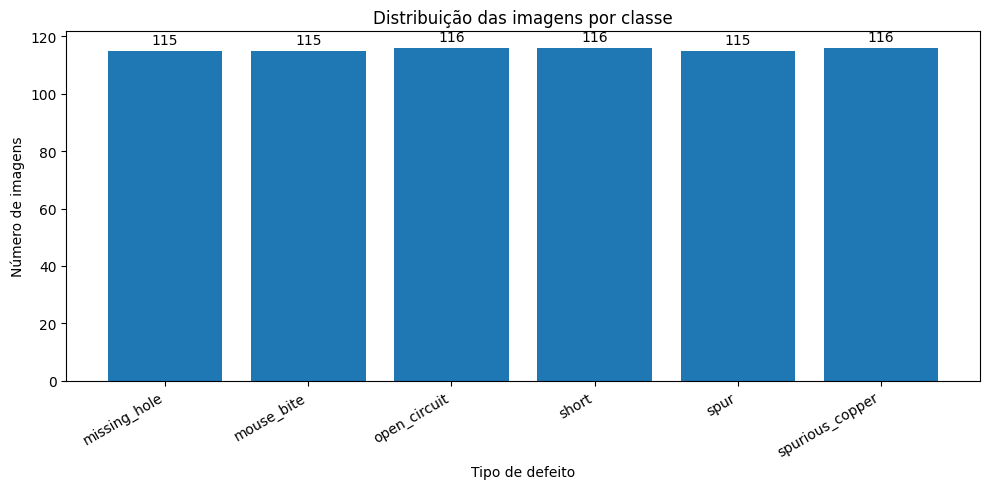

Figura salva em: /content/src/outputs/figures/01_class_distribution.png


In [7]:
# ============================================================
# 1.3 DISTRIBUIÇÃO DAS CLASSES
# ============================================================

ordered_distribution = (
    class_distribution
    .set_index("class_name")
    .reindex(CLASS_NAMES)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    ordered_distribution["class_name"],
    ordered_distribution["n_images"]
)

ax.set_title("Distribuição das imagens por classe")
ax.set_xlabel("Tipo de defeito")
ax.set_ylabel("Número de imagens")
ax.bar_label(bars, padding=3)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

figure_path = FIGURES_DIR / "01_class_distribution.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figura salva em: {figure_path}")


In [8]:
# ============================================================
# 1.4 ÍNDICE DAS ANOTAÇÕES
# ============================================================

annotation_records = []

for xml_path in sorted(ANNOTATIONS_DIR.rglob("*.xml")):
    root = ET.parse(xml_path).getroot()

    filename = root.findtext("filename")
    folder_name = root.findtext("folder") or xml_path.parent.name
    class_name = xml_path.parent.name.lower()

    image_path = IMAGES_DIR / folder_name / filename

    # Fallback para diferenças de casing/organização.
    if not image_path.exists():
        matches = list(IMAGES_DIR.rglob(filename))
        if not matches:
            raise FileNotFoundError(
                f"Imagem correspondente ao XML não encontrada: {xml_path}"
            )
        image_path = matches[0]

    # O prefixo identifica o layout-base da PCB (01, 02, ...).
    board_id = Path(filename).stem.split("_")[0]

    objects = root.findall("object")

    annotation_records.append({
        "image_path": str(image_path),
        "xml_path": str(xml_path),
        "filename": filename,
        "class_name": class_name,
        "board_id": board_id,
        "n_objects": len(objects),
    })

annotation_df = pd.DataFrame(annotation_records)

assert len(annotation_df) > 0
assert annotation_df["class_name"].isin(CLASS_NAMES).all()
assert (annotation_df["n_objects"] > 0).all()

display(annotation_df.head())

print(f"Imagens anotadas: {len(annotation_df)}")
print(f"Layouts-base (board_id): {annotation_df['board_id'].nunique()}")
print(f"Objetos anotados: {annotation_df['n_objects'].sum()}")
print(f"Média de defeitos por imagem: {annotation_df['n_objects'].mean():.2f}")

annotation_df.to_csv(
    METADATA_DIR / "annotation_index.csv",
    index=False
)


,image_path,xml_path,filename,class_name,board_id,n_objects
0,/content/src/data/raw/PCB_DATASET/images/Missi...,/content/src/data/raw/PCB_DATASET/Annotations/...,01_missing_hole_01.jpg,missing_hole,01,3
1,/content/src/data/raw/PCB_DATASET/images/Missi...,/content/src/data/raw/PCB_DATASET/Annotations/...,01_missing_hole_02.jpg,missing_hole,01,3
2,/content/src/data/raw/PCB_DATASET/images/Missi...,/content/src/data/raw/PCB_DATASET/Annotations/...,01_missing_hole_03.jpg,missing_hole,01,3
3,/content/src/data/raw/PCB_DATASET/images/Missi...,/content/src/data/raw/PCB_DATASET/Annotations/...,01_missing_hole_04.jpg,missing_hole,01,3
4,/content/src/data/raw/PCB_DATASET/images/Missi...,/content/src/data/raw/PCB_DATASET/Annotations/...,01_missing_hole_05.jpg,missing_hole,01,4


Imagens anotadas: 693
Layouts-base (board_id): 10
Objetos anotados: 2953
Média de defeitos por imagem: 4.26


In [9]:
# ============================================================
# 1.5 EXEMPLO DE ANOTAÇÃO
# ============================================================

sample_row = annotation_df.iloc[0]
sample_root = ET.parse(sample_row["xml_path"]).getroot()

print("Arquivo:", Path(sample_row["xml_path"]).name)
print("Imagem:", sample_row["filename"])
print("Objetos:", len(sample_root.findall("object")))

for i, obj in enumerate(sample_root.findall("object")[:5], start=1):
    box = obj.find("bndbox")
    print(
        f"{i}. {obj.findtext('name')} | "
        f"({box.findtext('xmin')}, {box.findtext('ymin')}) → "
        f"({box.findtext('xmax')}, {box.findtext('ymax')})"
    )


Arquivo: 01_missing_hole_01.xml
Imagem: 01_missing_hole_01.jpg
Objetos: 3
1. missing_hole | (2459, 1274) → (2530, 1329)
2. missing_hole | (1613, 334) → (1679, 396)
3. missing_hole | (1726, 794) → (1797, 854)


## 2. Partição sem vazamento

Em vez de dividir os arquivos aleatoriamente, usamos `board_id` como grupo. Dessa forma, o mesmo layout-base de PCB não aparece simultaneamente em treino e teste.

`StratifiedGroupKFold` combina duas preocupações:

- **grupo:** mantém cada `board_id` em uma única partição;
- **estratificação:** tenta preservar a distribuição das seis classes.

Usamos aproximadamente **4/6 dos grupos para treino, 1/6 para validação e 1/6 para teste**.


In [10]:
# ============================================================
# 2.1 SPLIT ESTRATIFICADO POR GRUPO
# ============================================================

splitter = StratifiedGroupKFold(
    n_splits=6,
    shuffle=True,
    random_state=SEED
)

fold_id = np.full(len(annotation_df), -1, dtype=int)

for fold, (_, fold_indices) in enumerate(
    splitter.split(
        annotation_df,
        y=annotation_df["class_name"],
        groups=annotation_df["board_id"]
    )
):
    fold_id[fold_indices] = fold

annotation_df = annotation_df.copy()
annotation_df["fold"] = fold_id

assert (annotation_df["fold"] >= 0).all()

TEST_FOLD = 0
VAL_FOLD = 1

train_image_df = annotation_df[
    ~annotation_df["fold"].isin([TEST_FOLD, VAL_FOLD])
].reset_index(drop=True)

val_image_df = annotation_df[
    annotation_df["fold"] == VAL_FOLD
].reset_index(drop=True)

test_image_df = annotation_df[
    annotation_df["fold"] == TEST_FOLD
].reset_index(drop=True)

train_groups = set(train_image_df["board_id"])
val_groups = set(val_image_df["board_id"])
test_groups = set(test_image_df["board_id"])

assert train_groups.isdisjoint(val_groups)
assert train_groups.isdisjoint(test_groups)
assert val_groups.isdisjoint(test_groups)

for split_name, split_df in {
    "Treino": train_image_df,
    "Validação": val_image_df,
    "Teste": test_image_df,
}.items():
    missing = set(CLASS_NAMES) - set(split_df["class_name"])
    assert not missing, f"{split_name} ficou sem as classes: {missing}"

split_summary = pd.DataFrame({
    "Treino": train_image_df["class_name"].value_counts(),
    "Validação": val_image_df["class_name"].value_counts(),
    "Teste": test_image_df["class_name"].value_counts(),
}).reindex(CLASS_NAMES).fillna(0).astype(int)

display(split_summary)

print("\nBoards de treino:", sorted(train_groups))
print("Boards de validação:", sorted(val_groups))
print("Boards de teste:", sorted(test_groups))
print("\n✓ Nenhum board_id aparece em mais de uma partição.")

annotation_df.to_csv(
    METADATA_DIR / "annotation_index_with_split.csv",
    index=False
)


,Treino,Validação,Teste
class_name,,,
missing_hole,75,20,20
mouse_bite,75,20,20
open_circuit,76,20,20
short,76,20,20
spur,75,20,20
spurious_copper,76,20,20



Boards de treino: ['01', '04', '05', '06', '09', '10']
Boards de validação: ['11', '12']
Boards de teste: ['07', '08']

✓ Nenhum board_id aparece em mais de uma partição.


In [11]:
# ============================================================
# 2.2 MAPEAMENTO DAS CLASSES
# ============================================================

class_to_index = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}

index_to_class = {
    index: class_name
    for class_name, index in class_to_index.items()
}

for class_name, index in class_to_index.items():
    print(f"{index} -> {class_name}")


0 -> missing_hole
1 -> mouse_bite
2 -> open_circuit
3 -> short
4 -> spur
5 -> spurious_copper


In [12]:
# ============================================================
# 2.3 CARREGAMENTO E PIPELINE TF.DATA
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE


def load_image(filepath, label):
    image = tf.io.read_file(filepath)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Ajuda o TensorFlow a conhecer o número de canais.
    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        antialias=True
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image, label


def dataframe_to_dataset(df, shuffle=False):
    filepaths = df["image_path"].values

    labels = (
        df["class_name"]
        .map(class_to_index)
        .astype("int32")
        .values
    )

    if pd.isna(labels).any():
        raise ValueError("Há labels sem mapeamento.")

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


global_train_ds = dataframe_to_dataset(
    train_image_df,
    shuffle=True
)

global_val_ds = dataframe_to_dataset(
    val_image_df
)

global_test_ds = dataframe_to_dataset(
    test_image_df
)

print("✓ Datasets de imagem completa criados.")


✓ Datasets de imagem completa criados.


## 3. Baseline com a PCB completa

A primeira referência utiliza a imagem completa. O objetivo não é maximizar a acurácia, mas testar se o defeito ainda é visível para a CNN depois de reduzir uma PCB de alta resolução para `128 × 128`.

Já nesta baseline são usados:

- **data augmentation** leve;
- **EarlyStopping**;
- **ModelCheckpoint**;
- **ReduceLROnPlateau**.

O conjunto de **teste continua intocado**: esta etapa é diagnosticada apenas pela validação.


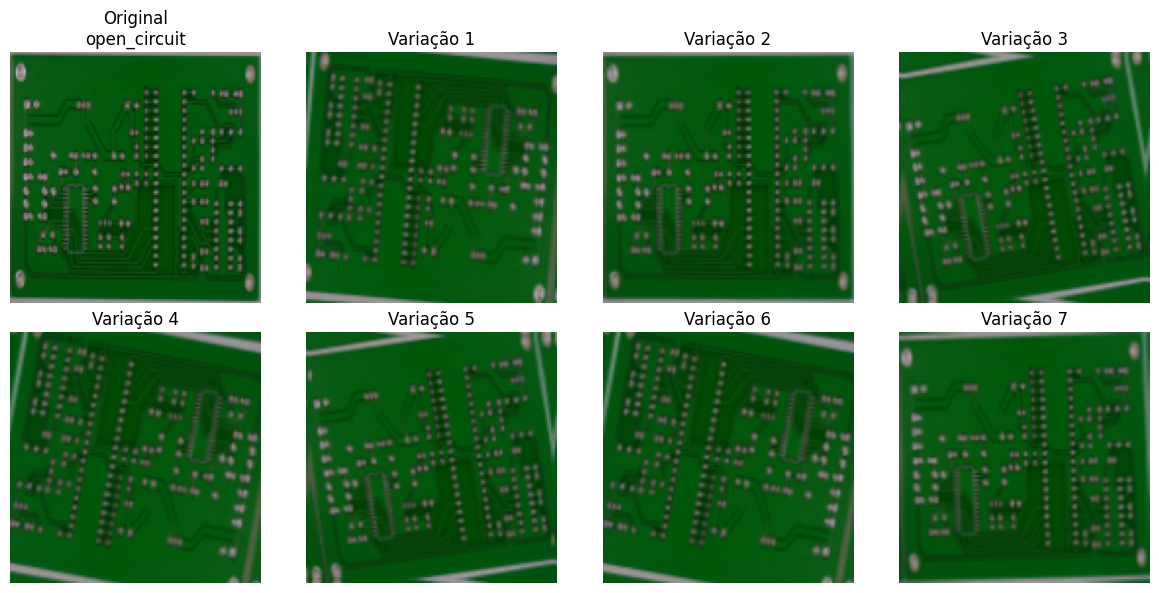

In [13]:
# ============================================================
# 3.1 DATA AUGMENTATION — IMAGEM COMPLETA
# ============================================================

global_augmentation = keras.Sequential([
    layers.RandomFlip(
        "horizontal_and_vertical",
        seed=SEED
    ),
    layers.RandomRotation(
        0.03,
        fill_mode="reflect",
        seed=SEED
    ),
    layers.RandomZoom(
        0.04,
        fill_mode="reflect",
        seed=SEED
    ),
], name="global_augmentation")

images, labels = next(iter(global_train_ds))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

sample_image = images[0]
sample_label = int(labels[0].numpy())

axes[0].imshow(sample_image)
axes[0].set_title(f"Original\n{index_to_class[sample_label]}")
axes[0].axis("off")

for i in range(1, 8):
    augmented = global_augmentation(
        tf.expand_dims(sample_image, 0),
        training=True
    )[0]

    axes[i].imshow(tf.clip_by_value(augmented, 0, 1))
    axes[i].set_title(f"Variação {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [14]:
# ============================================================
# 3.2 CNN BASELINE GLOBAL
# ============================================================

global_baseline = keras.Sequential([
    layers.Input(shape=(*IMAGE_SIZE, 3)),
    global_augmentation,

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="global_baseline")

global_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

global_baseline.summary()


Model: "global_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ global_augmentation             │ (None, 128, 128, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,942 (93.52 KB)

 Trainable params: 23,942 (93.52 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# ============================================================
# 3.3 CALLBACKS E TREINAMENTO DA BASELINE GLOBAL
# ============================================================

GLOBAL_BASELINE_PATH = MODELS_DIR / "global_baseline_best.keras"

global_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=GLOBAL_BASELINE_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

global_history = global_baseline.fit(
    global_train_ds,
    validation_data=global_val_ds,
    epochs=GLOBAL_BASELINE_EPOCHS,
    callbacks=global_callbacks,
    verbose=1
)


Epoch 1/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1777 - loss: 1.7929
Epoch 1: val_loss improved from None to 1.79200, saving model to /content/src/models/global_baseline_best.keras

Epoch 1: finished saving model to /content/src/models/global_baseline_best.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.1656 - loss: 1.7939 - val_accuracy: 0.1667 - val_loss: 1.7920 - learning_rate: 0.0010
Epoch 2/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1711 - loss: 1.7912
Epoch 2: val_loss improved from 1.79200 to 1.79183, saving model to /content/src/models/global_baseline_best.keras

Epoch 2: finished saving model to /content/src/models/global_baseline_best.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.1523 - loss: 1.7919 - val_accuracy: 0.1667 - val_loss: 1.7918 - learning_rate: 0.0010
Epoch 3/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1660 - loss: 1.7921
Epoch 3: val_loss did not improve from 1.79183
15/15 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/s

In [16]:
# ============================================================
# 3.4 DIAGNÓSTICO DA BASELINE GLOBAL
# ============================================================

global_val_loss, global_val_accuracy = global_baseline.evaluate(
    global_val_ds,
    verbose=0
)

global_probs = global_baseline.predict(
    global_val_ds,
    verbose=0
)

print(f"Validation loss:     {global_val_loss:.4f}")
print(f"Validation accuracy: {global_val_accuracy:.2%}")
print(f"Acaso (1/6):         {1 / NUM_CLASSES:.2%}")
print(f"Cross-entropy uniforme ln(6): {np.log(NUM_CLASSES):.4f}")

print("\nPrimeiras probabilidades:")
print(np.round(global_probs[:5], 3))


Validation loss:     1.7918
Validation accuracy: 16.67%
Acaso (1/6):         16.67%
Cross-entropy uniforme ln(6): 1.7918

Primeiras probabilidades:
[[0.164 0.166 0.169 0.166 0.165 0.17 ]
 [0.164 0.166 0.169 0.166 0.165 0.17 ]
 [0.164 0.166 0.169 0.166 0.165 0.17 ]
 [0.164 0.166 0.169 0.166 0.165 0.17 ]
 [0.164 0.166 0.169 0.166 0.165 0.17 ]]


### Leitura do diagnóstico

Quando `accuracy ≈ 1/6` e `loss ≈ ln(6)`, a rede está se comportando quase como um classificador uniforme. Isso não prova que a CNN seja incapaz: pode significar que **o defeito ocupa uma parcela pequena demais da imagem completa**.

A próxima etapa usa as *bounding boxes* já existentes para transformar cada defeito em uma amostra de classificação.


## 4. Extração das regiões de interesse (ROI)

Cada `<object>` do XML gera um *crop* independente. A *bounding box* recebe contexto adicional e é transformada em uma região aproximadamente quadrada, reduzindo a deformação causada pelo `resize`.

Os crops são gerados **depois** do split por `board_id`; portanto, objetos oriundos da mesma placa-base permanecem na mesma partição.


In [17]:
# ============================================================
# 4.1 FUNÇÕES DE RECORTE
# ============================================================

CROPS_DIR = PROCESSED_DIR / "crops"


def square_bbox(
    xmin, ymin, xmax, ymax,
    width, height,
    context_scale=ROI_CONTEXT_SCALE,
    min_side=ROI_MIN_SIDE
):
    box_w = xmax - xmin
    box_h = ymax - ymin

    if box_w <= 0 or box_h <= 0:
        raise ValueError("Bounding box inválida.")

    cx = (xmin + xmax) / 2
    cy = (ymin + ymax) / 2

    side = max(box_w, box_h) * context_scale
    side = max(side, min_side)

    x1 = int(round(cx - side / 2))
    y1 = int(round(cy - side / 2))
    x2 = int(round(cx + side / 2))
    y2 = int(round(cy + side / 2))

    # Desloca a janela se ultrapassar a borda.
    if x1 < 0:
        x2 -= x1
        x1 = 0

    if y1 < 0:
        y2 -= y1
        y1 = 0

    if x2 > width:
        x1 -= (x2 - width)
        x2 = width

    if y2 > height:
        y1 -= (y2 - height)
        y2 = height

    x1 = max(0, x1)
    y1 = max(0, y1)

    return x1, y1, x2, y2


def generate_crops(df, split_name):
    split_dir = CROPS_DIR / split_name

    # Reexecução idempotente: não mistura crops antigos com novos.
    if split_dir.exists():
        shutil.rmtree(split_dir)

    records = []
    skipped = 0

    for _, row in df.iterrows():
        image_path = Path(row["image_path"])
        xml_path = Path(row["xml_path"])

        root = ET.parse(xml_path).getroot()

        with Image.open(image_path) as image:
            image = image.convert("RGB")
            width, height = image.size

            for object_id, obj in enumerate(root.findall("object")):
                class_name = obj.findtext("name").lower()

                if class_name not in class_to_index:
                    skipped += 1
                    continue

                bbox = obj.find("bndbox")

                xmin = int(bbox.findtext("xmin"))
                ymin = int(bbox.findtext("ymin"))
                xmax = int(bbox.findtext("xmax"))
                ymax = int(bbox.findtext("ymax"))

                try:
                    x1, y1, x2, y2 = square_bbox(
                        xmin, ymin, xmax, ymax,
                        width, height
                    )
                except ValueError:
                    skipped += 1
                    continue

                crop = image.crop((x1, y1, x2, y2))

                class_dir = split_dir / class_name
                class_dir.mkdir(parents=True, exist_ok=True)

                crop_name = (
                    f"{row['board_id']}_"
                    f"{image_path.stem}_"
                    f"{object_id:02d}.jpg"
                )

                crop_path = class_dir / crop_name
                crop.save(crop_path, quality=95)

                records.append({
                    "filepath": str(crop_path),
                    "class_name": class_name,
                    "source_image": str(image_path),
                    "board_id": row["board_id"],
                    "object_id": object_id,
                    "xmin": xmin,
                    "ymin": ymin,
                    "xmax": xmax,
                    "ymax": ymax,
                    "crop_x1": x1,
                    "crop_y1": y1,
                    "crop_x2": x2,
                    "crop_y2": y2,
                })

    result = pd.DataFrame(records)
    print(
        f"{split_name}: {len(result)} crops gerados"
        f" | {skipped} objetos ignorados"
    )

    return result


In [18]:
# ============================================================
# 4.2 GERAÇÃO DOS CROPS
# ============================================================

crop_train_df = generate_crops(
    train_image_df,
    "train"
)

crop_val_df = generate_crops(
    val_image_df,
    "val"
)

crop_test_df = generate_crops(
    test_image_df,
    "test"
)

for split_name, split_df in {
    "train": crop_train_df,
    "val": crop_val_df,
    "test": crop_test_df,
}.items():
    missing = set(CLASS_NAMES) - set(split_df["class_name"])
    assert not missing, f"{split_name} ficou sem as classes: {missing}"

crop_distribution = pd.DataFrame({
    "Treino": crop_train_df["class_name"].value_counts(),
    "Validação": crop_val_df["class_name"].value_counts(),
    "Teste": crop_test_df["class_name"].value_counts(),
}).reindex(CLASS_NAMES).fillna(0).astype(int)

display(crop_distribution)

crop_train_df.to_csv(
    METADATA_DIR / "roi_train.csv",
    index=False
)
crop_val_df.to_csv(
    METADATA_DIR / "roi_val.csv",
    index=False
)
crop_test_df.to_csv(
    METADATA_DIR / "roi_test.csv",
    index=False
)

print(
    "\nTotal de crops:",
    len(crop_train_df) + len(crop_val_df) + len(crop_test_df)
)


train: 1749 crops gerados | 0 objetos ignorados
val: 606 crops gerados | 0 objetos ignorados
test: 598 crops gerados | 0 objetos ignorados


,Treino,Validação,Teste
class_name,,,
missing_hole,296,102,99
mouse_bite,292,100,100
open_circuit,281,101,100
short,291,101,99
spur,287,101,100
spurious_copper,302,101,100



Total de crops: 2953


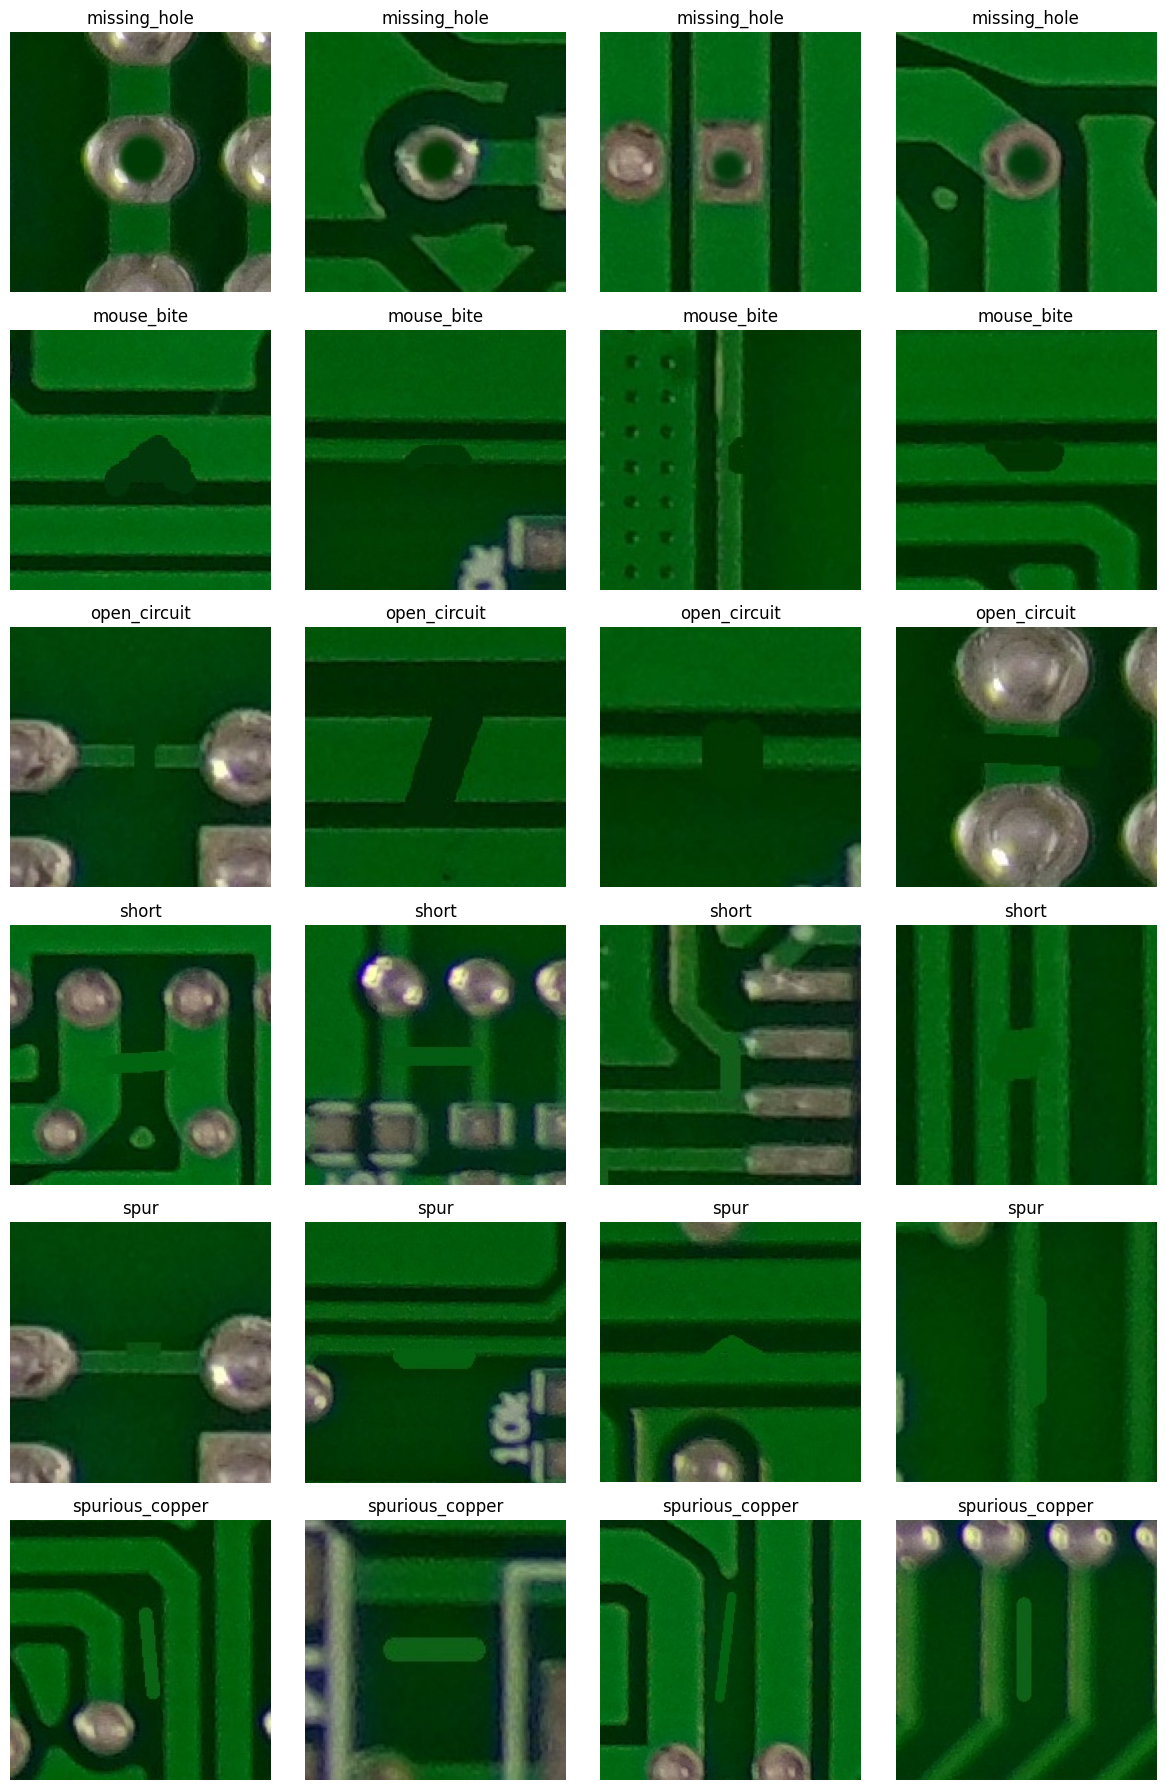

In [19]:
# ============================================================
# 4.3 VISUALIZAÇÃO DAS ROIs
# ============================================================

fig, axes = plt.subplots(
    len(CLASS_NAMES),
    4,
    figsize=(12, 3 * len(CLASS_NAMES))
)

for row, class_name in enumerate(CLASS_NAMES):
    samples = (
        crop_train_df[
            crop_train_df["class_name"] == class_name
        ]
        .sample(
            n=min(4, (crop_train_df["class_name"] == class_name).sum()),
            random_state=SEED
        )
    )

    for col in range(4):
        axes[row, col].axis("off")

    for col, (_, sample) in enumerate(samples.iterrows()):
        image = plt.imread(sample["filepath"])

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()

roi_samples_path = FIGURES_DIR / "02_roi_samples.png"
plt.savefig(
    roi_samples_path,
    dpi=150,
    bbox_inches="tight"
)
plt.show()


## 5. Pipeline de treinamento das ROIs

Agora cada amostra contém diretamente o defeito. O *data augmentation* permanece moderado para aumentar robustez sem alterar a semântica da classe.

Também calculamos **pesos de classe**. Eles só são aplicados quando o maior grupo de treino possui pelo menos 15% mais amostras que o menor.


In [20]:
# ============================================================
# 5.1 TF.DATA PARA OS CROPS
# ============================================================

def roi_dataframe_to_dataset(df, shuffle=False):
    filepaths = df["filepath"].values

    labels = (
        df["class_name"]
        .map(class_to_index)
        .astype("int32")
        .values
    )

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(df),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


roi_train_ds = roi_dataframe_to_dataset(
    crop_train_df,
    shuffle=True
)

# Versão sem shuffle: usada em embeddings, PCA, K-Means e outliers.
roi_train_eval_ds = roi_dataframe_to_dataset(
    crop_train_df,
    shuffle=False
)
roi_val_ds = roi_dataframe_to_dataset(
    crop_val_df
)
roi_test_ds = roi_dataframe_to_dataset(
    crop_test_df
)

print("✓ Datasets de ROI criados.")
print("✓ Dataset determinístico de treino criado para análises.")


✓ Datasets de ROI criados.
✓ Dataset determinístico de treino criado para análises.


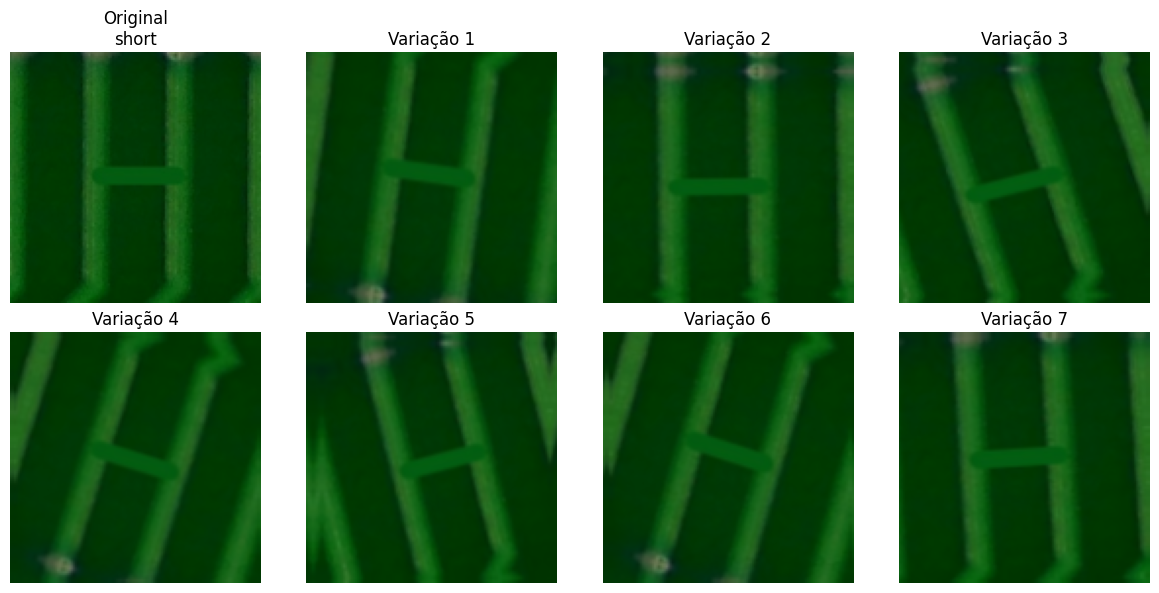

In [21]:
# ============================================================
# 5.2 DATA AUGMENTATION — ROI
# ============================================================

roi_augmentation = keras.Sequential([
    layers.RandomFlip(
        "horizontal_and_vertical",
        seed=SEED
    ),
    layers.RandomRotation(
        0.05,
        fill_mode="reflect",
        seed=SEED
    ),
    layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05,
        fill_mode="reflect",
        seed=SEED
    ),
    layers.RandomZoom(
        height_factor=(-0.08, 0.08),
        width_factor=(-0.08, 0.08),
        fill_mode="reflect",
        seed=SEED
    ),
    layers.RandomContrast(
        factor=0.10,
        seed=SEED
    ),
], name="roi_augmentation")

images, labels = next(iter(roi_train_ds))
sample_image = images[0]
sample_label = int(labels[0].numpy())

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

axes[0].imshow(sample_image)
axes[0].set_title(f"Original\n{index_to_class[sample_label]}")
axes[0].axis("off")

for i in range(1, 8):
    augmented = roi_augmentation(
        tf.expand_dims(sample_image, 0),
        training=True
    )[0]

    axes[i].imshow(
        tf.clip_by_value(augmented, 0, 1)
    )
    axes[i].set_title(f"Variação {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


In [22]:
# ============================================================
# 5.3 PESOS DE CLASSE
# ============================================================

train_counts = (
    crop_train_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
)

imbalance_ratio = (
    train_counts.max()
    / train_counts.min()
)

train_labels_numeric = (
    crop_train_df["class_name"]
    .map(class_to_index)
    .astype("int32")
    .values
)

if imbalance_ratio >= 1.15:
    classes_present = np.unique(train_labels_numeric)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes_present,
        y=train_labels_numeric
    )

    class_weights = {
        int(cls): float(weight)
        for cls, weight in zip(classes_present, weights)
    }

    print(
        f"Desbalanceamento detectado "
        f"(razão máx/mín = {imbalance_ratio:.2f})."
    )
    print("Pesos de classe ativados:")
    for class_idx, weight in class_weights.items():
        print(
            f"  {index_to_class[class_idx]:18s}: "
            f"{weight:.3f}"
        )
else:
    class_weights = None

    print(
        f"Classes suficientemente equilibradas "
        f"(razão máx/mín = {imbalance_ratio:.2f})."
    )
    print("Pesos de classe não serão aplicados.")


Classes suficientemente equilibradas (razão máx/mín = 1.07).
Pesos de classe não serão aplicados.


## 6. Baseline sobre as ROIs

Para medir o ganho obtido apenas pela mudança de representação, treinamos uma segunda baseline sobre os crops.

Além de `EarlyStopping` e checkpoint, usamos `ReduceLROnPlateau`: se a validação estagnar, a taxa de aprendizado é reduzida automaticamente.


In [23]:
# ============================================================
# 6.1 CNN BASELINE — ROI
# ============================================================

roi_baseline = keras.Sequential([
    layers.Input(shape=(*IMAGE_SIZE, 3)),
    roi_augmentation,

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax"),
], name="roi_baseline")

roi_baseline.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3,
        clipnorm=1.0
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(
            k=2,
            name="top2_accuracy"
        )
    ]
)

roi_baseline.summary()


Model: "roi_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ roi_augmentation (Sequential)   │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,942 (93.52 KB)

 Trainable params: 23,942 (93.52 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# ============================================================
# 6.2 CALLBACKS E TREINAMENTO DA ROI BASELINE
# ============================================================

ROI_BASELINE_PATH = MODELS_DIR / "roi_baseline_best.keras"
ROI_BASELINE_LOG = METRICS_DIR / "roi_baseline_history.csv"

roi_baseline_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=ROI_BASELINE_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.CSVLogger(
        ROI_BASELINE_LOG
    ),
]

roi_baseline_history = roi_baseline.fit(
    roi_train_ds,
    validation_data=roi_val_ds,
    epochs=ROI_BASELINE_EPOCHS,
    callbacks=roi_baseline_callbacks,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1787 - loss: 1.7891 - top2_accuracy: 0.3473
Epoch 1: val_loss improved from None to 1.74215, saving model to /content/src/models/roi_baseline_best.keras

Epoch 1: finished saving model to /content/src/models/roi_baseline_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 83ms/step - accuracy: 0.2047 - loss: 1.7808 - top2_accuracy: 0.3877 - val_accuracy: 0.2723 - val_loss: 1.7422 - val_top2_accuracy: 0.4637 - learning_rate: 0.0010
Epoch 2/20
54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2506 - loss: 1.7472 - top2_accuracy: 0.4462
Epoch 2: val_loss improved from 1.74215 to 1.70587, saving model to /content/src/models/roi_baseline_best.keras

Epoch 2: finished saving model to /content/src/models/roi_baseline_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.2516 - loss: 1.7341 - top2_accuracy: 0.4471 - val_accuracy: 0.2673 - val_loss: 1.7059 - val_top2_accuracy: 0.4554 - learning_rate: 0.0010
Epoch 3/20
55/55 ━━

In [25]:
# ============================================================
# 6.3 RESULTADO DE VALIDAÇÃO DA ROI BASELINE
# ============================================================

roi_baseline_val = roi_baseline.evaluate(
    roi_val_ds,
    verbose=0,
    return_dict=True
)

for metric, value in roi_baseline_val.items():
    print(f"{metric:18s}: {value:.4f}")


accuracy          : 0.2739
loss              : 1.6778
top2_accuracy     : 0.4274


## 7. CNN principal

A CNN principal aumenta a capacidade sem recorrer a uma camada `Flatten` muito grande. As principais melhorias são:

- `BatchNormalization` após as convoluções;
- regularização **L2**;
- `GlobalAveragePooling2D`;
- `Dropout`;
- taxa de aprendizado inicial menor;
- *gradient clipping*;
- `ReduceLROnPlateau`;
- `EarlyStopping`;
- melhor modelo persistido por `ModelCheckpoint`.

O objetivo é melhorar a **generalização**, não apenas a acurácia de treino.


In [26]:
# ============================================================
# 7.1 CNN PRINCIPAL
# ============================================================

main_model = keras.Sequential([
    layers.Input(shape=(*IMAGE_SIZE, 3)),
    roi_augmentation,

    layers.Conv2D(
        32, 3,
        padding="same",
        use_bias=False,
        kernel_regularizer=regularizers.l2(L2_FACTOR)
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(
        64, 3,
        padding="same",
        use_bias=False,
        kernel_regularizer=regularizers.l2(L2_FACTOR)
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(
        128, 3,
        padding="same",
        use_bias=False,
        kernel_regularizer=regularizers.l2(L2_FACTOR)
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(
        192, 3,
        padding="same",
        use_bias=False,
        kernel_regularizer=regularizers.l2(L2_FACTOR)
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(L2_FACTOR),
        name="embedding"
    ),
    layers.Dropout(MAIN_DROPOUT),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="classifier"
    ),
], name="pcb_cnn")

main_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=MAIN_LEARNING_RATE,
        clipnorm=1.0
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(
            k=2,
            name="top2_accuracy"
        )
    ]
)

main_model.summary()


Model: "pcb_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ roi_augmentation (Sequential)   │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 192)    │       221,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 192)    │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 192)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 192)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 341,350 (1.30 MB)

 Trainable params: 340,518 (1.30 MB)

 Non-trainable params: 832 (3.25 KB)

In [27]:
# ============================================================
# 7.2 CALLBACKS DA CNN PRINCIPAL
# ============================================================

MAIN_MODEL_PATH = MODELS_DIR / "pcb_cnn_best.keras"
MAIN_LOG_PATH = METRICS_DIR / "main_training_history.csv"

main_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=MAIN_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.CSVLogger(
        MAIN_LOG_PATH
    ),
]

print("Checkpoint:", MAIN_MODEL_PATH)


Checkpoint: /content/src/models/pcb_cnn_best.keras


In [28]:
# ============================================================
# 7.3 TREINAMENTO
# ============================================================

main_history = main_model.fit(
    roi_train_ds,
    validation_data=roi_val_ds,
    epochs=MAIN_EPOCHS,
    callbacks=main_callbacks,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/35
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2637 - loss: 1.7629 - top2_accuracy: 0.4676
Epoch 1: val_loss improved from None to 1.88333, saving model to /content/src/models/pcb_cnn_best.keras

Epoch 1: finished saving model to /content/src/models/pcb_cnn_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.3122 - loss: 1.6934 - top2_accuracy: 0.5226 - val_accuracy: 0.1667 - val_loss: 1.8833 - val_top2_accuracy: 0.3317 - learning_rate: 3.0000e-04
Epoch 2/35
54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4280 - loss: 1.5077 - top2_accuracy: 0.6112
Epoch 2: val_loss did not improve from 1.88333
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.4288 - loss: 1.4867 - top2_accuracy: 0.6387 - val_accuracy: 0.1667 - val_loss: 2.0356 - val_top2_accuracy: 0.3333 - learning_rate: 3.0000e-04
Epoch 3/35
54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.4497 - loss: 1.4134 - top2_accuracy: 0.6838
Epoch 3: val_loss did not improve from 1.88333

Epoch 3:

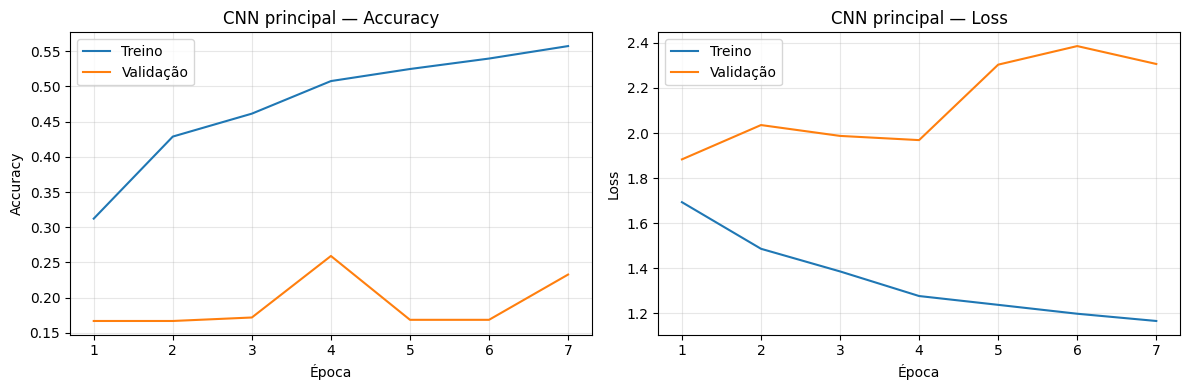

In [29]:
# ============================================================
# 7.4 CURVAS DE APRENDIZADO
# ============================================================

history = main_history.history
epochs_range = range(1, len(history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    epochs_range,
    history["accuracy"],
    label="Treino"
)
axes[0].plot(
    epochs_range,
    history["val_accuracy"],
    label="Validação"
)
axes[0].set_title("CNN principal — Accuracy")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs_range,
    history["loss"],
    label="Treino"
)
axes[1].plot(
    epochs_range,
    history["val_loss"],
    label="Validação"
)
axes[1].set_title("CNN principal — Loss")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

training_path = FIGURES_DIR / "03_main_training_curves.png"
plt.savefig(
    training_path,
    dpi=150,
    bbox_inches="tight"
)
plt.show()


## 7.5 Benchmark complementar — Transfer Learning

Além da CNN construída do zero, usamos uma **MobileNetV2 pré-treinada em ImageNet** como benchmark de baixo esforço.

O backbone permanece congelado e apenas a cabeça de classificação é treinada. Como nossas imagens já estão normalizadas para `[0,1]`, uma camada de `Rescaling` converte a entrada para `[-1,1]`, intervalo esperado pela MobileNetV2.

O objetivo não é substituir a CNN principal, mas responder:

**uma representação visual pré-treinada consegue competir com a arquitetura desenvolvida especificamente para as ROIs de PCB?**


In [30]:
# ============================================================
# 7.5.1 MOBILENETV2 — BACKBONE CONGELADO
# ============================================================

transfer_base = keras.applications.MobileNetV2(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

transfer_base.trainable = False

transfer_inputs = keras.Input(
    shape=(*IMAGE_SIZE, 3),
    name="transfer_input"
)

x = roi_augmentation(transfer_inputs)

# As imagens do pipeline estão em [0,1].
# MobileNetV2 trabalha com entrada equivalente a [-1,1].
x = layers.Rescaling(
    scale=2.0,
    offset=-1.0,
    name="mobilenet_rescaling"
)(x)

x = transfer_base(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D(
    name="transfer_gap"
)(x)

x = layers.Dropout(
    TRANSFER_DROPOUT,
    name="transfer_dropout"
)(x)

transfer_outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="transfer_classifier"
)(x)

transfer_model = keras.Model(
    transfer_inputs,
    transfer_outputs,
    name="mobilenetv2_transfer"
)

transfer_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=TRANSFER_LEARNING_RATE,
        clipnorm=1.0
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(
            k=2,
            name="top2_accuracy"
        )
    ]
)

transfer_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ transfer_input (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ roi_augmentation (Sequential)   │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_rescaling (Rescaling) │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_gap                    │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_dropout (Dropout)      │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_classifier (Dense)     │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [31]:
# ============================================================
# 7.5.2 CALLBACKS E TREINAMENTO DO BENCHMARK
# ============================================================

TRANSFER_MODEL_PATH = (
    MODELS_DIR
    / "mobilenetv2_transfer_best.keras"
)

TRANSFER_LOG_PATH = (
    METRICS_DIR
    / "transfer_training_history.csv"
)

transfer_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=TRANSFER_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.CSVLogger(
        TRANSFER_LOG_PATH
    ),
]

transfer_history = transfer_model.fit(
    roi_train_ds,
    validation_data=roi_val_ds,
    epochs=TRANSFER_EPOCHS,
    callbacks=transfer_callbacks,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.2000 - loss: 2.3641 - top2_accuracy: 0.3867
Epoch 1: val_loss improved from None to 1.54432, saving model to /content/src/models/mobilenetv2_transfer_best.keras

Epoch 1: finished saving model to /content/src/models/mobilenetv2_transfer_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - accuracy: 0.2567 - loss: 2.0303 - top2_accuracy: 0.4545 - val_accuracy: 0.3845 - val_loss: 1.5443 - val_top2_accuracy: 0.5858 - learning_rate: 3.0000e-04
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.3974 - loss: 1.6128 - top2_accuracy: 0.5712
Epoch 2: val_loss improved from 1.54432 to 1.32528, saving model to /content/src/models/mobilenetv2_transfer_best.keras

Epoch 2: finished saving model to /content/src/models/mobilenetv2_transfer_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.4208 - loss: 1.5647 - top2_accuracy: 0.6038 - val_accuracy: 0.4785 - val_loss: 1.3253 - val_top2_accuracy: 0.6634 - lea

In [32]:
# ============================================================
# 7.5.3 RESULTADO DE VALIDAÇÃO — TRANSFER LEARNING
# ============================================================

transfer_val = transfer_model.evaluate(
    roi_val_ds,
    verbose=0,
    return_dict=True
)

print("MobileNetV2 — validação")
print("-" * 40)

for metric, value in transfer_val.items():
    print(f"{metric:18s}: {value:.4f}")


MobileNetV2 — validação
----------------------------------------
accuracy          : 0.6304
loss              : 0.9260
top2_accuracy     : 0.8168


## 7.6 Segunda tentativa de CNN própria: normalização + regularização espacial

Os resultados anteriores revelaram um comportamento importante:

- a CNN principal aumentou a acurácia de treino, mas não generalizou para os `board_id` de validação;
- a MobileNetV2 congelada generalizou muito melhor.

Uma hipótese plausível é que a CNN própria esteja aprendendo características muito específicas dos layouts presentes no treino. Nesta segunda tentativa aplicamos três mudanças simples:

1. **`Normalization` adaptada somente no treino**, padronizando cada canal a partir da média e variância das ROIs de treinamento;
2. **`LayerNormalization`** no lugar de `BatchNormalization`, evitando dependência das estatísticas móveis dos batches;
3. **`SpatialDropout2D` + Dropout** para reduzir coadaptação excessiva dos mapas de características.

Também usamos convoluções separáveis, reduzindo o número de parâmetros.


In [33]:
# ============================================================
# 7.6.1 NORMALIZAÇÃO ADAPTADA SOMENTE NO TREINO
# ============================================================

train_images_only = roi_train_eval_ds.map(
    lambda images, labels: images
)

input_normalization = layers.Normalization(
    axis=-1,
    name="train_channel_normalization"
)

input_normalization.adapt(
    train_images_only
)

print("Média aprendida:")
print(np.asarray(input_normalization.mean).reshape(-1))

print("\nVariância aprendida:")
print(np.asarray(input_normalization.variance).reshape(-1))


Média aprendida:
[0.0536349  0.30071795 0.0746232 ]

Variância aprendida:
[0.0169031  0.01068408 0.01074962]


In [34]:
# ============================================================
# 7.6.2 CNN NORMALIZADA E REGULARIZADA
# ============================================================

ENHANCED_CNN_EPOCHS = 30
ENHANCED_CNN_LR = 2e-4
ENHANCED_CNN_DROPOUT = 0.40
ENHANCED_CNN_PATH = MODELS_DIR / "normalized_cnn_best.keras"

enhanced_inputs = keras.Input(
    shape=(*IMAGE_SIZE, 3),
    name="enhanced_input"
)

x = roi_augmentation(enhanced_inputs)
x = input_normalization(x)

for filters, spatial_dropout in [
    (32, 0.08),
    (64, 0.10),
    (128, 0.15),
]:
    x = layers.SeparableConv2D(
        filters,
        3,
        padding="same",
        use_bias=False
    )(x)

    x = layers.LayerNormalization(
        axis=-1
    )(x)

    x = layers.Activation(
        "gelu"
    )(x)

    x = layers.SeparableConv2D(
        filters,
        3,
        padding="same",
        use_bias=False
    )(x)

    x = layers.LayerNormalization(
        axis=-1
    )(x)

    x = layers.Activation(
        "gelu"
    )(x)

    x = layers.MaxPooling2D()(x)

    x = layers.SpatialDropout2D(
        spatial_dropout
    )(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(
    128,
    activation="gelu",
    name="embedding"
)(x)

x = layers.Dropout(
    ENHANCED_CNN_DROPOUT
)(x)

enhanced_outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="enhanced_classifier"
)(x)

enhanced_cnn = keras.Model(
    enhanced_inputs,
    enhanced_outputs,
    name="normalized_cnn"
)

enhanced_cnn.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=ENHANCED_CNN_LR,
        clipnorm=1.0
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(
            k=2,
            name="top2_accuracy"
        )
    ]
)

enhanced_cnn.summary()


Model: "normalized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ enhanced_input (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ roi_augmentation (Sequential)   │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ train_channel_normalization     │ (None, 128, 128, 3)    │             7 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 128, 128, 32)   │           123 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 128, 128, 32)   │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 128, 128, 32)   │         1,312 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 128, 128, 32)   │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 64, 64, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 64, 64, 64)     │         2,336 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 64, 64, 64)     │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 64, 64, 64)     │         4,672 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 64, 64, 64)     │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 32, 32, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 52,936 (206.79 KB)

 Trainable params: 52,929 (206.75 KB)

 Non-trainable params: 7 (32.00 B)

In [ ]:
# ============================================================
# 7.6.3 TREINAMENTO DA CNN NORMALIZADA
# ============================================================

enhanced_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=ENHANCED_CNN_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

enhanced_history = enhanced_cnn.fit(
    roi_train_ds,
    validation_data=roi_val_ds,
    epochs=ENHANCED_CNN_EPOCHS,
    callbacks=enhanced_callbacks,
    class_weight=class_weights,
    verbose=1
)


Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.1605 - loss: 1.9824 - top2_accuracy: 0.3324
Epoch 1: val_loss improved from None to 1.75937, saving model to /content/src/models/normalized_cnn_best.keras

Epoch 1: finished saving model to /content/src/models/normalized_cnn_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 17s 192ms/step - accuracy: 0.1624 - loss: 1.9153 - top2_accuracy: 0.3391 - val_accuracy: 0.2228 - val_loss: 1.7594 - val_top2_accuracy: 0.3993 - learning_rate: 2.0000e-04
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.1869 - loss: 1.8279 - top2_accuracy: 0.3676
Epoch 2: val_loss improved from 1.75937 to 1.74221, saving model to /content/src/models/normalized_cnn_best.keras

Epoch 2: finished saving model to /content/src/models/normalized_cnn_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 210ms/step - accuracy: 0.1864 - loss: 1.8213 - top2_accuracy: 0.3705 - val_accuracy: 0.2459 - val_loss: 1.7422 - val_top2_accuracy: 0.3762 - learning_rate: 2.0000e-

## 7.7 Fine-tuning da MobileNetV2

O benchmark congelado já apresentou desempenho muito superior às CNNs treinadas do zero. O passo seguinte é permitir uma adaptação controlada das camadas mais profundas da MobileNetV2 ao domínio de PCBs.

O procedimento é conservador:

- carregamos o **melhor checkpoint** do treinamento congelado;
- liberamos apenas as últimas camadas convolucionais do backbone;
- mantemos todas as camadas `BatchNormalization` congeladas;
- utilizamos uma taxa de aprendizado muito pequena (`1e-5`);
- mantemos `EarlyStopping`, checkpoint e redução automática da taxa de aprendizado.

Essa etapa costuma ser mais eficaz que aumentar arbitrariamente a profundidade de uma CNN treinada do zero.


In [ ]:
# ============================================================
# 7.7.1 PREPARAÇÃO DO FINE-TUNING
# ============================================================

FINETUNE_EPOCHS = 15
FINETUNE_LR = 1e-5
FINETUNE_LAST_LAYERS = 30

FINETUNE_MODEL_PATH = (
    MODELS_DIR
    / "mobilenetv2_finetuned_best.keras"
)

finetune_model = keras.models.load_model(
    TRANSFER_MODEL_PATH
)

backbone_candidates = [
    layer
    for layer in finetune_model.layers
    if isinstance(layer, keras.Model)
    and "mobilenetv2" in layer.name.lower()
]

if not backbone_candidates:
    raise RuntimeError(
        "Backbone MobileNetV2 não encontrado."
    )

finetune_backbone = backbone_candidates[0]
finetune_backbone.trainable = True

# Congela a maior parte do backbone.
for layer in finetune_backbone.layers[:-FINETUNE_LAST_LAYERS]:
    layer.trainable = False

# BatchNorm permanece congelada para evitar instabilidade
# com dataset pequeno e mudança de domínio.
for layer in finetune_backbone.layers[-FINETUNE_LAST_LAYERS:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

trainable_backbone_layers = sum(
    int(layer.trainable)
    for layer in finetune_backbone.layers
)

print(
    "Camadas treináveis no backbone:",
    trainable_backbone_layers,
    "/",
    len(finetune_backbone.layers)
)

finetune_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=FINETUNE_LR,
        clipnorm=1.0
    ),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.SparseTopKCategoricalAccuracy(
            k=2,
            name="top2_accuracy"
        )
    ]
)


In [ ]:
# ============================================================
# 7.7.2 TREINAMENTO DO FINE-TUNING
# ============================================================

finetune_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=FINETUNE_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
]

finetune_history = finetune_model.fit(
    roi_train_ds,
    validation_data=roi_val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=finetune_callbacks,
    class_weight=class_weights,
    verbose=1
)


## 8. Seleção do modelo e avaliação final

Uma correção importante em relação à versão anterior é feita aqui.

A versão anterior comparava os modelos, mas as etapas seguintes continuavam usando a **CNN principal**, mesmo quando a MobileNetV2 era muito superior. Isso fazia a matriz de confusão, a calibração e a taxonomia de erros refletirem o modelo errado.

Agora:

1. todos os candidatos são avaliados na **validação**;
2. o melhor modelo é escolhido por **Macro-F1 de validação**;
3. somente então o modelo selecionado é analisado no teste;
4. as análises posteriores usam sempre `selected_model`.

O conjunto de teste não participa da escolha do modelo.


In [ ]:
# ============================================================
# 8.1 FUNÇÕES DE AVALIAÇÃO
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

def collect_labels(dataset):
    return np.concatenate([
        labels.numpy()
        for _, labels in dataset
    ])


def evaluate_classifier(
    model,
    dataset,
    model_name
):
    y_true_local = collect_labels(
        dataset
    )

    probs = model.predict(
        dataset,
        verbose=0
    )

    y_pred_local = np.argmax(
        probs,
        axis=1
    )

    precision_macro, recall_macro, f1_macro, _ = (
        precision_recall_fscore_support(
            y_true_local,
            y_pred_local,
            average="macro",
            zero_division=0
        )
    )

    _, _, f1_weighted, _ = (
        precision_recall_fscore_support(
            y_true_local,
            y_pred_local,
            average="weighted",
            zero_division=0
        )
    )

    top2 = np.mean([
        true in np.argsort(prob)[-2:]
        for true, prob
        in zip(
            y_true_local,
            probs
        )
    ])

    results = {
        "model": model_name,
        "accuracy": accuracy_score(
            y_true_local,
            y_pred_local
        ),
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_f1": f1_weighted,
        "top2_accuracy": top2,
    }

    return (
        results,
        y_true_local,
        y_pred_local,
        probs
    )


In [ ]:
# ============================================================
# 8.2 CARREGAR OS MELHORES CHECKPOINTS
# ============================================================

candidate_models = {
    "roi_baseline": keras.models.load_model(
        ROI_BASELINE_PATH
    ),
    "pcb_cnn": keras.models.load_model(
        MAIN_MODEL_PATH
    ),
    "mobilenetv2_frozen": keras.models.load_model(
        TRANSFER_MODEL_PATH
    ),
    "normalized_cnn": keras.models.load_model(
        ENHANCED_CNN_PATH
    ),
    "mobilenetv2_finetuned": keras.models.load_model(
        FINETUNE_MODEL_PATH
    ),
}

print("Modelos candidatos:")
for model_name in candidate_models:
    print(" -", model_name)


In [ ]:
# ============================================================
# 8.3 SELEÇÃO PELO MACRO-F1 DE VALIDAÇÃO
# ============================================================

validation_rows = []

for model_name, model in candidate_models.items():
    metrics, _, _, _ = evaluate_classifier(
        model,
        roi_val_ds,
        model_name
    )

    validation_rows.append(
        metrics
    )

validation_comparison_df = (
    pd.DataFrame(
        validation_rows
    )
    .sort_values(
        "macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    validation_comparison_df.style.format({
        "accuracy": "{:.2%}",
        "macro_precision": "{:.2%}",
        "macro_recall": "{:.2%}",
        "macro_f1": "{:.2%}",
        "weighted_f1": "{:.2%}",
        "top2_accuracy": "{:.2%}",
    })
)

SELECTED_MODEL_NAME = (
    validation_comparison_df
    .iloc[0]["model"]
)

selected_model = candidate_models[
    SELECTED_MODEL_NAME
]

print(
    "\nModelo selecionado exclusivamente pela validação:",
    SELECTED_MODEL_NAME
)


In [ ]:
# ============================================================
# 8.4 COMPARAÇÃO FINAL NO TESTE
# ============================================================

test_rows = []

for model_name, model in candidate_models.items():
    metrics, _, _, _ = evaluate_classifier(
        model,
        roi_test_ds,
        model_name
    )

    test_rows.append(
        metrics
    )

test_comparison_df = (
    pd.DataFrame(
        test_rows
    )
    .sort_values(
        "macro_f1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    test_comparison_df.style.format({
        "accuracy": "{:.2%}",
        "macro_precision": "{:.2%}",
        "macro_recall": "{:.2%}",
        "macro_f1": "{:.2%}",
        "weighted_f1": "{:.2%}",
        "top2_accuracy": "{:.2%}",
    })
)

selected_results, y_true, y_pred, y_probs_raw = (
    evaluate_classifier(
        selected_model,
        roi_test_ds,
        SELECTED_MODEL_NAME
    )
)

validation_comparison_df.to_csv(
    METRICS_DIR
    / "validation_model_comparison.csv",
    index=False
)

test_comparison_df.to_csv(
    METRICS_DIR
    / "test_model_comparison.csv",
    index=False
)


In [ ]:
# ============================================================
# 8.5 CLASSIFICATION REPORT DO MODELO SELECIONADO
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    labels=range(NUM_CLASSES),
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

classification_report_df = (
    pd.DataFrame(
        report_dict
    )
    .transpose()
)

display(
    classification_report_df
)

classification_report_df.to_csv(
    METRICS_DIR
    / "classification_report_selected_model.csv"
)


In [ ]:
# ============================================================
# 8.6 MATRIZES DE CONFUSÃO
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=range(NUM_CLASSES)
)

row_sum = cm.sum(
    axis=1,
    keepdims=True
)

cm_norm = np.divide(
    cm,
    row_sum,
    out=np.zeros_like(
        cm,
        dtype=float
    ),
    where=row_sum != 0
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

for ax, matrix, title, fmt in [
    (
        axes[0],
        cm,
        "Matriz de confusão — valores absolutos",
        "d"
    ),
    (
        axes[1],
        cm_norm,
        "Matriz de confusão — normalizada",
        ".2f"
    ),
]:
    ax.imshow(matrix)

    ax.set_xticks(
        range(NUM_CLASSES)
    )
    ax.set_yticks(
        range(NUM_CLASSES)
    )

    ax.set_xticklabels(
        CLASS_NAMES,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(
        CLASS_NAMES
    )

    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_title(
        f"{title}\n{SELECTED_MODEL_NAME}"
    )

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(
                j,
                i,
                format(
                    matrix[i, j],
                    fmt
                ),
                ha="center",
                va="center"
            )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "selected_model_confusion_matrices.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


## 9. Calibração das probabilidades do modelo selecionado

A versão anterior calibrava a CNN principal mesmo quando ela estava próxima do acaso. Isso produzia um ECE pequeno apenas porque as probabilidades eram quase uniformes — o que **não significa boa classificação**.

Agora a calibração é aplicada ao modelo escolhido pela validação.

O `temperature scaling` é ajustado **somente na validação** e depois aplicado ao teste.


In [ ]:
# ============================================================
# 9.1 FUNÇÕES DE CALIBRAÇÃO
# ============================================================

from scipy.optimize import minimize_scalar

def stable_softmax(logits):
    logits = np.asarray(
        logits,
        dtype=np.float64
    )

    logits = (
        logits
        - logits.max(
            axis=1,
            keepdims=True
        )
    )

    exp_logits = np.exp(
        logits
    )

    return (
        exp_logits
        / exp_logits.sum(
            axis=1,
            keepdims=True
        )
    )


def probs_to_equivalent_logits(probs):
    probs = np.clip(
        np.asarray(
            probs,
            dtype=np.float64
        ),
        1e-12,
        1.0
    )

    return np.log(
        probs
    )


def apply_temperature(
    logits,
    temperature
):
    return stable_softmax(
        logits
        / temperature
    )


def negative_log_likelihood(
    y_true_local,
    probs
):
    true_probs = probs[
        np.arange(
            len(y_true_local)
        ),
        y_true_local
    ]

    return float(
        -np.mean(
            np.log(
                np.clip(
                    true_probs,
                    1e-12,
                    1.0
                )
            )
        )
    )


def expected_calibration_error(
    y_true_local,
    probs,
    n_bins=10
):
    confidence_local = (
        probs.max(axis=1)
    )

    prediction_local = (
        probs.argmax(axis=1)
    )

    correct_local = (
        prediction_local
        == y_true_local
    )

    edges = np.linspace(
        0.0,
        1.0,
        n_bins + 1
    )

    rows = []
    ece = 0.0

    for bin_idx in range(
        n_bins
    ):
        lower = edges[
            bin_idx
        ]

        upper = edges[
            bin_idx + 1
        ]

        if bin_idx == 0:
            mask = (
                (confidence_local >= lower)
                & (confidence_local <= upper)
            )
        else:
            mask = (
                (confidence_local > lower)
                & (confidence_local <= upper)
            )

        count = int(
            mask.sum()
        )

        if count == 0:
            rows.append({
                "bin": bin_idx,
                "count": 0,
                "mean_confidence": np.nan,
                "accuracy": np.nan,
                "gap": np.nan,
            })
            continue

        mean_confidence = float(
            confidence_local[
                mask
            ].mean()
        )

        bin_accuracy = float(
            correct_local[
                mask
            ].mean()
        )

        gap = abs(
            bin_accuracy
            - mean_confidence
        )

        ece += (
            count
            / len(
                y_true_local
            )
        ) * gap

        rows.append({
            "bin": bin_idx,
            "count": count,
            "mean_confidence": mean_confidence,
            "accuracy": bin_accuracy,
            "gap": gap,
        })

    return (
        float(ece),
        pd.DataFrame(rows)
    )


In [ ]:
# ============================================================
# 9.2 TEMPERATURE SCALING — FIT SOMENTE NA VALIDAÇÃO
# ============================================================

y_val = collect_labels(
    roi_val_ds
)

val_probs_raw = selected_model.predict(
    roi_val_ds,
    verbose=0
)

val_logits_equiv = (
    probs_to_equivalent_logits(
        val_probs_raw
    )
)

test_logits_equiv = (
    probs_to_equivalent_logits(
        y_probs_raw
    )
)


def validation_nll_from_log_temperature(
    log_temperature
):
    temperature_local = float(
        np.exp(
            log_temperature
        )
    )

    calibrated = apply_temperature(
        val_logits_equiv,
        temperature_local
    )

    return negative_log_likelihood(
        y_val,
        calibrated
    )


temperature_search = minimize_scalar(
    validation_nll_from_log_temperature,
    bounds=(
        np.log(0.05),
        np.log(10.0)
    ),
    method="bounded"
)

temperature = float(
    np.exp(
        temperature_search.x
    )
)

y_probs_calibrated = (
    apply_temperature(
        test_logits_equiv,
        temperature
    )
)

y_pred_calibrated = np.argmax(
    y_probs_calibrated,
    axis=1
)

assert np.array_equal(
    y_pred,
    y_pred_calibrated
)

print(
    f"Modelo: {SELECTED_MODEL_NAME}"
)

print(
    f"Temperatura ótima: "
    f"{temperature:.4f}"
)


In [ ]:
# ============================================================
# 9.3 ECE, NLL E RELIABILITY DIAGRAM
# ============================================================

ece_raw, reliability_raw = (
    expected_calibration_error(
        y_true,
        y_probs_raw,
        n_bins=10
    )
)

ece_cal, reliability_cal = (
    expected_calibration_error(
        y_true,
        y_probs_calibrated,
        n_bins=10
    )
)

nll_raw = negative_log_likelihood(
    y_true,
    y_probs_raw
)

nll_cal = negative_log_likelihood(
    y_true,
    y_probs_calibrated
)

calibration_summary = pd.DataFrame([
    {
        "probabilities": "raw",
        "ece": ece_raw,
        "nll": nll_raw,
        "temperature": 1.0,
    },
    {
        "probabilities": "temperature_scaled",
        "ece": ece_cal,
        "nll": nll_cal,
        "temperature": temperature,
    },
])

display(
    calibration_summary
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

for ax, table, title, ece_value in [
    (
        axes[0],
        reliability_raw,
        "Antes da calibração",
        ece_raw
    ),
    (
        axes[1],
        reliability_cal,
        "Após temperature scaling",
        ece_cal
    ),
]:
    valid = table[
        table["count"] > 0
    ]

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfeito"
    )

    ax.plot(
        valid["mean_confidence"],
        valid["accuracy"],
        marker="o",
        label="Modelo"
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel(
        "Confiança média"
    )
    ax.set_ylabel(
        "Acurácia observada"
    )
    ax.set_title(
        f"{title}\nECE={ece_value:.4f}"
    )
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "selected_model_reliability.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


In [ ]:
# ============================================================
# 9.4 INCERTEZA CALIBRADA
# ============================================================

confidence = (
    y_probs_calibrated.max(
        axis=1
    )
)

sorted_probs = np.sort(
    y_probs_calibrated,
    axis=1
)

top2_margin = (
    sorted_probs[:, -1]
    - sorted_probs[:, -2]
)

entropy = -np.sum(
    y_probs_calibrated
    * np.log(
        y_probs_calibrated
        + 1e-12
    ),
    axis=1
)

correct = (
    y_pred == y_true
)

probability_summary = pd.DataFrame({
    "grupo": [
        "Corretas",
        "Incorretas"
    ],
    "n": [
        int(correct.sum()),
        int((~correct).sum())
    ],
    "confianca_media": [
        confidence[correct].mean()
        if correct.any()
        else np.nan,

        confidence[~correct].mean()
        if (~correct).any()
        else np.nan,
    ],
    "entropia_media": [
        entropy[correct].mean()
        if correct.any()
        else np.nan,

        entropy[~correct].mean()
        if (~correct).any()
        else np.nan,
    ],
    "margem_top2_media": [
        top2_margin[correct].mean()
        if correct.any()
        else np.nan,

        top2_margin[~correct].mean()
        if (~correct).any()
        else np.nan,
    ],
})

display(
    probability_summary
)


## 10. Análise no domínio da frequência

A FFT 2D é usada como **análise complementar**, não como novo classificador. O espectro mostra como a informação espacial está distribuída em frequências.

Além da visualização, calculamos uma razão simples de energia em altas frequências após remover a média da imagem.


In [ ]:
# ============================================================
# 10.1 FFT 2D
# ============================================================

def prepare_gray_image(image_path):
    image = Image.open(
        image_path
    ).convert("L")

    image = image.resize(
        IMAGE_SIZE
    )

    return (
        np.asarray(image)
        .astype(np.float32)
        / 255.0
    )


def fft_magnitude(gray):
    centered = gray - gray.mean()

    fft = np.fft.fft2(centered)
    fft_shift = np.fft.fftshift(fft)

    return np.log1p(
        np.abs(fft_shift)
    )


def high_frequency_ratio(gray, radius_fraction=0.18):
    centered = gray - gray.mean()

    spectrum = np.abs(
        np.fft.fftshift(
            np.fft.fft2(centered)
        )
    ) ** 2

    h, w = spectrum.shape

    yy, xx = np.ogrid[:h, :w]

    cy = (h - 1) / 2
    cx = (w - 1) / 2

    radius = np.sqrt(
        (yy - cy) ** 2
        + (xx - cx) ** 2
    )

    high_mask = (
        radius
        > radius_fraction * min(h, w)
    )

    total = spectrum.sum()

    if total <= 0:
        return 0.0

    return float(
        spectrum[high_mask].sum()
        / total
    )


In [ ]:
# ============================================================
# 10.2 AMOSTRAS E ESPECTROS
# ============================================================

fig, axes = plt.subplots(
    NUM_CLASSES,
    2,
    figsize=(10, 3 * NUM_CLASSES)
)

for row, class_name in enumerate(CLASS_NAMES):
    class_df = crop_test_df[
        crop_test_df["class_name"]
        == class_name
    ]

    sample = class_df.sample(
        n=1,
        random_state=SEED
    ).iloc[0]

    gray = prepare_gray_image(
        sample["filepath"]
    )

    magnitude = fft_magnitude(gray)

    axes[row, 0].imshow(
        gray,
        cmap="gray"
    )
    axes[row, 0].set_title(class_name)
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        magnitude,
        cmap="gray"
    )
    axes[row, 1].set_title(
        f"FFT — {class_name}"
    )
    axes[row, 1].axis("off")

plt.tight_layout()

fft_path = FIGURES_DIR / "07_fft_samples.png"
plt.savefig(
    fft_path,
    dpi=150,
    bbox_inches="tight"
)
plt.show()


In [ ]:
# ============================================================
# 10.3 ENERGIA DE ALTA FREQUÊNCIA POR CLASSE
# ============================================================

fft_rows = []

for _, row in crop_test_df.iterrows():
    gray = prepare_gray_image(
        row["filepath"]
    )

    fft_rows.append({
        "class_name": row["class_name"],
        "high_frequency_ratio": (
            high_frequency_ratio(gray)
        )
    })

fft_df = pd.DataFrame(fft_rows)

fft_summary = (
    fft_df
    .groupby("class_name")
    ["high_frequency_ratio"]
    .agg(["mean", "std", "count"])
    .reindex(CLASS_NAMES)
)

display(fft_summary)

fft_summary.to_csv(
    METRICS_DIR / "fft_summary.csv"
)


## 11. Álgebra linear sobre os embeddings: PCA e whitening

As análises de representação passam a usar **o modelo selecionado**, e não a CNN que colapsou.

Duas transformações são aplicadas exclusivamente com `fit` no treino:

- `StandardScaler`;
- **PCA com whitening** para o K-Means.

O whitening é uma transformação linear que decorrelaciona os componentes principais e os coloca em escalas comparáveis. Isso é particularmente útil para métodos baseados em distância Euclidiana, como K-Means.

Para visualização, uma segunda PCA com apenas duas componentes é utilizada sem alterar o treinamento do classificador.


In [ ]:
# ============================================================
# 11.1 EXTRAÇÃO ROBUSTA DOS EMBEDDINGS
# ============================================================

def choose_embedding_layer(model):
    preferred_names = [
        "embedding",
        "transfer_gap",
    ]

    for name in preferred_names:
        try:
            return model.get_layer(
                name
            )
        except ValueError:
            pass

    # Fallback: última camada 2D antes do classificador.
    for layer in reversed(
        model.layers[:-1]
    ):
        try:
            shape = tuple(
                layer.output.shape
            )
        except Exception:
            continue

        if len(shape) == 2:
            return layer

    raise RuntimeError(
        "Camada de embedding não encontrada."
    )


embedding_layer = choose_embedding_layer(
    selected_model
)

print(
    "Camada usada como embedding:",
    embedding_layer.name
)

embedding_model = keras.Model(
    inputs=selected_model.inputs,
    outputs=embedding_layer.output
)

train_embeddings = (
    embedding_model.predict(
        roi_train_eval_ds,
        verbose=0
    )
)

test_embeddings = (
    embedding_model.predict(
        roi_test_ds,
        verbose=0
    )
)

y_train_embed = collect_labels(
    roi_train_eval_ds
)

print(
    "Train embeddings:",
    train_embeddings.shape
)

print(
    "Test embeddings:",
    test_embeddings.shape
)


In [ ]:
# ============================================================
# 11.2 PCA + WHITENING AJUSTADOS SOMENTE NO TREINO
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score
)

embedding_scaler = StandardScaler()

train_scaled = (
    embedding_scaler.fit_transform(
        train_embeddings
    )
)

test_scaled = (
    embedding_scaler.transform(
        test_embeddings
    )
)

# PCA 2D apenas para visualização.
pca_vis = PCA(
    n_components=2,
    random_state=SEED
)

train_pca_2d = pca_vis.fit_transform(
    train_scaled
)

test_pca_2d = pca_vis.transform(
    test_scaled
)

# PCA whitening para clustering.
max_components = min(
    32,
    train_scaled.shape[1],
    train_scaled.shape[0] - 1
)

pca_whiten = PCA(
    n_components=max_components,
    whiten=True,
    random_state=SEED
)

train_whitened = (
    pca_whiten.fit_transform(
        train_scaled
    )
)

test_whitened = (
    pca_whiten.transform(
        test_scaled
    )
)

print(
    "Componentes usados no whitening:",
    max_components
)

print(
    "Variância explicada acumulada:",
    f"{pca_whiten.explained_variance_ratio_.sum():.2%}"
)


In [ ]:
# ============================================================
# 11.3 K-MEANS SOBRE O ESPAÇO PCA-WHITENED
# ============================================================

kmeans = KMeans(
    n_clusters=NUM_CLASSES,
    random_state=SEED,
    n_init=20
)

train_clusters = (
    kmeans.fit_predict(
        train_whitened
    )
)

test_clusters = (
    kmeans.predict(
        test_whitened
    )
)

silhouette_train = silhouette_score(
    train_whitened,
    train_clusters
)

silhouette_test = (
    silhouette_score(
        test_whitened,
        test_clusters
    )
    if 1 < len(
        np.unique(
            test_clusters
        )
    ) < len(
        test_clusters
    )
    else np.nan
)

ari_test = adjusted_rand_score(
    y_true,
    test_clusters
)

print(
    f"Silhouette treino: "
    f"{silhouette_train:.4f}"
)

print(
    f"Silhouette teste: "
    f"{silhouette_test:.4f}"
)

print(
    f"ARI teste: "
    f"{ari_test:.4f}"
)


In [ ]:
# ============================================================
# 11.4 VISUALIZAÇÃO PCA
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

for class_idx, class_name in enumerate(
    CLASS_NAMES
):
    mask = (
        y_true == class_idx
    )

    axes[0].scatter(
        test_pca_2d[mask, 0],
        test_pca_2d[mask, 1],
        label=class_name,
        alpha=0.7
    )

axes[0].set_title(
    "PCA — classes reais"
)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(fontsize=8)

for cluster_idx in range(
    NUM_CLASSES
):
    mask = (
        test_clusters
        == cluster_idx
    )

    axes[1].scatter(
        test_pca_2d[mask, 0],
        test_pca_2d[mask, 1],
        label=f"Cluster {cluster_idx}",
        alpha=0.7
    )

axes[1].set_title(
    "K-Means no espaço PCA-whitened"
)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=8)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "selected_model_pca_kmeans.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


## 12. Taxonomia de erros e outliers

A análise de outliers agora usa os **embeddings do modelo selecionado**.

Os centróides e os limiares de distância são calculados exclusivamente no treino. Uma amostra de teste é considerada possível outlier quando sua distância ao centróide da classe real ultrapassa o percentil 95 observado para aquela classe no treinamento.


In [ ]:
# ============================================================
# 12.1 TAXONOMIA DOS ERROS
# ============================================================

off_diag = []

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if (
            i != j
            and cm[i, j] > 0
        ):
            off_diag.append(
                (
                    cm[i, j],
                    i,
                    j
                )
            )

off_diag = sorted(
    off_diag,
    reverse=True
)

top_confusion_pairs = {
    (i, j)
    for _, i, j
    in off_diag[:3]
}

# Centrόides aprendidos no treino.
class_centroids = {}
class_outlier_thresholds = {}

for class_idx in range(
    NUM_CLASSES
):
    mask = (
        y_train_embed
        == class_idx
    )

    class_train = (
        train_whitened[
            mask
        ]
    )

    centroid = (
        class_train.mean(
            axis=0
        )
    )

    class_centroids[
        class_idx
    ] = centroid

    distances = np.linalg.norm(
        class_train
        - centroid,
        axis=1
    )

    class_outlier_thresholds[
        class_idx
    ] = float(
        np.quantile(
            distances,
            0.95
        )
    )

test_embedding_distance = np.array([
    np.linalg.norm(
        embedding
        - class_centroids[
            int(true_class)
        ]
    )
    for embedding, true_class
    in zip(
        test_whitened,
        y_true
    )
])

threshold_per_sample = np.array([
    class_outlier_thresholds[
        int(true_class)
    ]
    for true_class in y_true
])

taxonomy_rows = []

test_meta = (
    crop_test_df
    .reset_index(
        drop=True
    )
)

for idx_error in np.where(
    ~correct
)[0]:
    tags = []

    if (
        top2_margin[
            idx_error
        ]
        < 0.15
    ):
        tags.append(
            "E1_ambiguo"
        )

    if (
        confidence[
            idx_error
        ]
        >= 0.80
    ):
        tags.append(
            "E2_alta_confianca"
        )

    if (
        (
            int(y_true[idx_error]),
            int(y_pred[idx_error])
        )
        in top_confusion_pairs
    ):
        tags.append(
            "E3_confusao_recorrente"
        )

    if (
        test_embedding_distance[
            idx_error
        ]
        >= threshold_per_sample[
            idx_error
        ]
    ):
        tags.append(
            "E4_possivel_outlier"
        )

    taxonomy_rows.append({
        "filepath": test_meta.loc[
            idx_error,
            "filepath"
        ],
        "classe_real": index_to_class[
            int(
                y_true[
                    idx_error
                ]
            )
        ],
        "classe_predita": index_to_class[
            int(
                y_pred[
                    idx_error
                ]
            )
        ],
        "confianca": confidence[
            idx_error
        ],
        "entropia": entropy[
            idx_error
        ],
        "margem_top2": top2_margin[
            idx_error
        ],
        "distancia_embedding": (
            test_embedding_distance[
                idx_error
            ]
        ),
        "limiar_outlier_treino": (
            threshold_per_sample[
                idx_error
            ]
        ),
        "taxonomia": (
            " | ".join(tags)
            if tags
            else "erro_comum"
        ),
    })

error_taxonomy_df = pd.DataFrame(
    taxonomy_rows
)

display(
    error_taxonomy_df.head(15)
)

error_taxonomy_df.to_csv(
    METRICS_DIR
    / "error_taxonomy_selected_model.csv",
    index=False
)


## 13. Inferência individual

A inferência final usa o **modelo selecionado pela validação** e retorna probabilidades calibradas.


In [ ]:
# ============================================================
# 13.1 INFERÊNCIA FINAL
# ============================================================

def predict_roi(
    image_path,
    top_k=3
):
    image_path = Path(
        image_path
    )

    image = tf.io.read_file(
        str(image_path)
    )

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape(
        [None, None, 3]
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        antialias=True
    )

    image = (
        tf.cast(
            image,
            tf.float32
        )
        / 255.0
    )

    raw_probs = selected_model.predict(
        tf.expand_dims(
            image,
            0
        ),
        verbose=0
    )[0]

    calibrated_probs = (
        apply_temperature(
            probs_to_equivalent_logits(
                raw_probs[None, :]
            ),
            temperature
        )[0]
    )

    pred_idx = int(
        np.argmax(
            calibrated_probs
        )
    )

    top_indices = np.argsort(
        calibrated_probs
    )[::-1][:top_k]

    result = {
        "model": SELECTED_MODEL_NAME,
        "classe": index_to_class[
            pred_idx
        ],
        "confianca_calibrada": float(
            calibrated_probs[
                pred_idx
            ]
        ),
        "top_k": [
            {
                "classe": index_to_class[
                    int(idx)
                ],
                "probabilidade": float(
                    calibrated_probs[
                        idx
                    ]
                ),
            }
            for idx in top_indices
        ],
    }

    plt.figure(
        figsize=(5, 5)
    )

    plt.imshow(image)
    plt.title(
        f"{result['classe']} — "
        f"{result['confianca_calibrada']:.1%}"
    )
    plt.axis("off")
    plt.show()

    return result


sample_path = (
    crop_test_df
    .iloc[0]["filepath"]
)

predict_roi(
    sample_path
)


## 14. Resultados consolidados

Os artefatos finais registram:

- modelo selecionado;
- comparação de validação e teste;
- parâmetros das etapas adicionais;
- calibração;
- PCA whitening e clustering;
- taxonomia de erros.


In [ ]:
# ============================================================
# 14.1 PREDICTIONS.CSV
# ============================================================

predictions_df = (
    crop_test_df
    .reset_index(drop=True)
    .copy()
)

predictions_df[
    "true_class"
] = [
    index_to_class[
        int(x)
    ]
    for x in y_true
]

predictions_df[
    "predicted_class"
] = [
    index_to_class[
        int(x)
    ]
    for x in y_pred
]

predictions_df[
    "correct"
] = correct

predictions_df[
    "confidence_calibrated"
] = confidence

predictions_df[
    "entropy_calibrated"
] = entropy

predictions_df[
    "top2_margin_calibrated"
] = top2_margin

for class_idx, class_name in enumerate(
    CLASS_NAMES
):
    predictions_df[
        f"p_raw_{class_name}"
    ] = y_probs_raw[
        :,
        class_idx
    ]

    predictions_df[
        f"p_cal_{class_name}"
    ] = y_probs_calibrated[
        :,
        class_idx
    ]

predictions_df.to_csv(
    METRICS_DIR
    / "predictions_selected_model.csv",
    index=False
)


In [ ]:
# ============================================================
# 14.2 RESULTADOS.JSON
# ============================================================

results = {
    "selected_model": (
        SELECTED_MODEL_NAME
    ),

    "selection_metric": (
        "validation_macro_f1"
    ),

    "selected_model_test": {
        key: float(value)
        for key, value
        in selected_results.items()
        if key != "model"
    },

    "validation_models": (
        validation_comparison_df
        .to_dict(
            orient="records"
        )
    ),

    "test_models": (
        test_comparison_df
        .to_dict(
            orient="records"
        )
    ),

    "optimization": {
        "normalized_cnn": {
            "input_normalization": (
                "keras.layers.Normalization "
                "fit on train only"
            ),
            "layer_normalization": True,
            "spatial_dropout": True,
            "dropout": (
                ENHANCED_CNN_DROPOUT
            ),
        },
        "mobilenet_finetuning": {
            "last_layers": (
                FINETUNE_LAST_LAYERS
            ),
            "learning_rate": (
                FINETUNE_LR
            ),
            "batchnorm_frozen": True,
        },
    },

    "calibration": {
        "temperature": float(
            temperature
        ),
        "ece_raw": float(
            ece_raw
        ),
        "ece_calibrated": float(
            ece_cal
        ),
        "nll_raw": float(
            nll_raw
        ),
        "nll_calibrated": float(
            nll_cal
        ),
        "fit_split": "validation",
    },

    "linear_algebra": {
        "embedding_layer": (
            embedding_layer.name
        ),
        "scaler_fit_split": "train",
        "pca_fit_split": "train",
        "pca_whitening": True,
        "pca_components": int(
            max_components
        ),
        "explained_variance": float(
            pca_whiten
            .explained_variance_ratio_
            .sum()
        ),
        "silhouette_train": float(
            silhouette_train
        ),
        "silhouette_test": (
            float(
                silhouette_test
            )
            if not np.isnan(
                silhouette_test
            )
            else None
        ),
        "ari_test": float(
            ari_test
        ),
    },
}

results_path = (
    METRICS_DIR
    / "resultados_otimizados.json"
)

with results_path.open(
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        results,
        file,
        indent=2,
        ensure_ascii=False
    )

print(
    "Resultados salvos em:",
    results_path
)


## 15. Síntese

A versão otimizada diferencia claramente três situações:

- **CNN principal original:** experimento útil para mostrar falha de generalização;
- **CNN normalizada:** verifica se normalização explícita + LayerNorm + dropout espacial reduzem essa falha;
- **MobileNetV2 com fine-tuning:** explora características pré-treinadas e adaptação ao domínio específico.

O modelo final é escolhido por **Macro-F1 de validação**, e todas as análises posteriores passam a usar esse modelo.

Isso evita interpretar como resultado final uma CNN que tenha colapsado para uma única classe.


In [ ]:
# ============================================================
# 15.1 RESUMO AUTOMÁTICO
# ============================================================

print("MODELO SELECIONADO")
print("=" * 60)
print(SELECTED_MODEL_NAME)

print()
print("TESTE")
print("-" * 60)

print(
    f"Accuracy: "
    f"{selected_results['accuracy']:.2%}"
)

print(
    f"Macro-F1: "
    f"{selected_results['macro_f1']:.2%}"
)

print(
    f"Top-2: "
    f"{selected_results['top2_accuracy']:.2%}"
)

print()
print("CALIBRAÇÃO")
print("-" * 60)

print(
    f"Temperatura: "
    f"{temperature:.4f}"
)

print(
    f"ECE raw → calibrado: "
    f"{ece_raw:.4f} → "
    f"{ece_cal:.4f}"
)

print(
    f"NLL raw → calibrado: "
    f"{nll_raw:.4f} → "
    f"{nll_cal:.4f}"
)

print()
print("ÁLGEBRA LINEAR / EMBEDDINGS")
print("-" * 60)

print(
    f"PCA whitening: "
    f"{max_components} componentes"
)

print(
    f"Silhouette teste: "
    f"{silhouette_test:.4f}"
)

print(
    f"ARI teste: "
    f"{ari_test:.4f}"
)


### O que esperar desta versão

A principal meta não é forçar artificialmente uma acurácia alta, mas corrigir o fluxo experimental e aplicar melhorias com justificativa:

- o modelo final não é escolhido pelo teste;
- normalização é aprendida somente no treino;
- `Dropout` e `SpatialDropout2D` são usados para reduzir sobreajuste;
- `BatchNormalization` não é usada na nova CNN própria;
- o fine-tuning usa taxa de aprendizado baixa e mantém BatchNorm congelada;
- PCA/K-Means e centróides de outliers são ajustados somente no treino;
- a calibração é aplicada ao modelo realmente selecionado.

Se o fine-tuning superar a MobileNetV2 congelada, isso representa um ganho real de adaptação ao domínio. Caso contrário, o checkpoint congelado continua sendo uma solução válida e mais simples.
